<a href="https://colab.research.google.com/github/sdg331/BDA/blob/main/12w_pandas_cookbook_ko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 12주차 pandas 활용 실습 정리

## 0. 기본 준비

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 40)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 2)

In [2]:
# 표를 옆으로 보기 위한 함수
from IPython.display import display_html

def view_tables(*tables):
    html = ""
    for t in tables:
        html += t.to_html() + "&nbsp;" * 4
    display_html(html.replace("table", "table style='display:inline'"), raw=True)

## 1. 기본 DataFrame 만들기

In [3]:
# 도서 판매 데이터
books = pd.DataFrame({
    "order_id": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008],
    "branch": ["서울", "부산", "서울", "대전", "부산", "서울", "대전", "부산"],
    "category": ["소설", "IT", "인문", "소설", "IT", "인문", "IT", "소설"],
    "book": ["파이썬입문", "데이터분석", "철학노트", "문학산책", "AI기초", "역사읽기", "SQL실습", "시집"],
    "qty": [2, 1, 3, 2, 4, 1, 2, 5],
    "unit_price": [18000, 32000, 15000, 14000, 28000, 16000, 25000, 12000],
    "member": ["Y", "N", "Y", "Y", "N", "Y", "N", "Y"]
})
books

,order_id,branch,category,book,qty,unit_price,member
0,1001,서울,소설,파이썬입문,2,18000,Y
1,1002,부산,IT,데이터분석,1,32000,N
2,1003,서울,인문,철학노트,3,15000,Y
3,1004,대전,소설,문학산책,2,14000,Y
4,1005,부산,IT,AI기초,4,28000,N
5,1006,서울,인문,역사읽기,1,16000,Y
6,1007,대전,IT,SQL실습,2,25000,N
7,1008,부산,소설,시집,5,12000,Y


In [4]:
# 매출액 계산
books["sales"] = books["qty"] * books["unit_price"]
books

,order_id,branch,category,book,qty,unit_price,member,sales
0,1001,서울,소설,파이썬입문,2,18000,Y,36000
1,1002,부산,IT,데이터분석,1,32000,N,32000
2,1003,서울,인문,철학노트,3,15000,Y,45000
3,1004,대전,소설,문학산책,2,14000,Y,28000
4,1005,부산,IT,AI기초,4,28000,N,112000
5,1006,서울,인문,역사읽기,1,16000,Y,16000
6,1007,대전,IT,SQL실습,2,25000,N,50000
7,1008,부산,소설,시집,5,12000,Y,60000


In [5]:
# 기본 정보 확인
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   order_id    8 non-null      int64 
 1   branch      8 non-null      object
 2   category    8 non-null      object
 3   book        8 non-null      object
 4   qty         8 non-null      int64 
 5   unit_price  8 non-null      int64 
 6   member      8 non-null      object
 7   sales       8 non-null      int64 
dtypes: int64(4), object(4)
memory usage: 644.0+ bytes


In [6]:
# 통계 확인
books.describe()

,order_id,qty,unit_price,sales
count,8.00,8.00,8.00,8.00
mean,1004.50,2.50,20000.00,47375.00
std,2.45,1.41,7348.47,29456.69
min,1001.00,1.00,12000.00,16000.00
25%,1002.75,1.75,14750.00,31000.00
50%,1004.50,2.00,17000.00,40500.00
75%,1006.25,3.25,25750.00,52500.00
max,1008.00,5.00,32000.00,112000.00


In [7]:
# 문자형 포함 요약
books.describe(include="all")

,order_id,branch,category,book,qty,unit_price,member,sales
count,8.00,8,8,8,8.00,8.00,8,8.00
unique,NaN,3,3,8,NaN,NaN,2,NaN
top,NaN,서울,소설,파이썬입문,NaN,NaN,Y,NaN
freq,NaN,3,3,1,NaN,NaN,5,NaN
mean,1004.50,NaN,NaN,NaN,2.50,20000.00,NaN,47375.00
std,2.45,NaN,NaN,NaN,1.41,7348.47,NaN,29456.69
min,1001.00,NaN,NaN,NaN,1.00,12000.00,NaN,16000.00
25%,1002.75,NaN,NaN,NaN,1.75,14750.00,NaN,31000.00
50%,1004.50,NaN,NaN,NaN,2.00,17000.00,NaN,40500.00
75%,1006.25,NaN,NaN,NaN,3.25,25750.00,NaN,52500.00


## 2. 조건에 따라 값 바꾸기

In [8]:
# 원본 보호를 위해 복사본 생성
df = books.copy()
df

,order_id,branch,category,book,qty,unit_price,member,sales
0,1001,서울,소설,파이썬입문,2,18000,Y,36000
1,1002,부산,IT,데이터분석,1,32000,N,32000
2,1003,서울,인문,철학노트,3,15000,Y,45000
3,1004,대전,소설,문학산책,2,14000,Y,28000
4,1005,부산,IT,AI기초,4,28000,N,112000
5,1006,서울,인문,역사읽기,1,16000,Y,16000
6,1007,대전,IT,SQL실습,2,25000,N,50000
7,1008,부산,소설,시집,5,12000,Y,60000


In [9]:
# 조건에 맞는 행 확인
df.loc[df["qty"] >= 3]

,order_id,branch,category,book,qty,unit_price,member,sales
2,1003,서울,인문,철학노트,3,15000,Y,45000
4,1005,부산,IT,AI기초,4,28000,N,112000
7,1008,부산,소설,시집,5,12000,Y,60000


In [10]:
# 판매 수량이 3권 이상이면 비고 표시
df.loc[df["qty"] >= 3, "note"] = "다량구매"
df

,order_id,branch,category,book,qty,unit_price,member,sales,note
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,NaN
1,1002,부산,IT,데이터분석,1,32000,N,32000,NaN
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매
3,1004,대전,소설,문학산책,2,14000,Y,28000,NaN
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매
5,1006,서울,인문,역사읽기,1,16000,Y,16000,NaN
6,1007,대전,IT,SQL실습,2,25000,N,50000,NaN
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매


In [11]:
# 결측값을 일반구매로 채우기
df["note"] = df["note"].fillna("일반구매")
df

,order_id,branch,category,book,qty,unit_price,member,sales,note
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매
5,1006,서울,인문,역사읽기,1,16000,Y,16000,일반구매
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매


In [12]:
# 회원이면 10% 할인, 아니면 0원
df["discount"] = np.where(df["member"] == "Y", df["sales"] * 0.1, 0)
df

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매,0.0
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매,4500.0
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800.0
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0
5,1006,서울,인문,역사읽기,1,16000,Y,16000,일반구매,1600.0
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매,6000.0


In [13]:
# 결제금액 계산
df["pay"] = df["sales"] - df["discount"]
df

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매,4500.0,40500.0
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0,112000.0
5,1006,서울,인문,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매,6000.0,54000.0


In [14]:
# 여러 조건에 따라 등급 지정
conditions = [
    df["pay"] >= 60000,
    df["pay"] >= 30000,
    df["pay"] < 30000
]

choices = ["상", "중", "하"]

df["pay_level"] = np.select(conditions, choices, default="기타")
df

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0,중
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매,4500.0,40500.0,중
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0,하
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상
5,1006,서울,인문,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0,하
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매,6000.0,54000.0,중


In [15]:
# where 사용
# 조건이 True면 기존 값 유지, False면 다른 값으로 대체
df["member_label"] = df["member"].where(df["member"] == "Y", "비회원")
df

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,Y
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0,중,비회원
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매,4500.0,40500.0,중,Y
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0,하,Y
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상,비회원
5,1006,서울,인문,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0,하,Y
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매,6000.0,54000.0,중,Y


In [16]:
# 회원 Y를 회원으로 바꾸기
df["member_label"] = df["member_label"].replace({"Y": "회원"})
df

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0,중,비회원
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매,4500.0,40500.0,중,회원
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0,하,회원
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상,비회원
5,1006,서울,인문,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0,하,회원
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매,6000.0,54000.0,중,회원


## 3. 행과 열 선택

In [17]:
# 하나의 열 선택
df["book"]

,book
0,파이썬입문
1,데이터분석
2,철학노트
3,문학산책
4,AI기초
5,역사읽기
6,SQL실습
7,시집


In [18]:
# 여러 열 선택
df[["branch", "category", "book", "pay"]]

,branch,category,book,pay
0,서울,소설,파이썬입문,32400.0
1,부산,IT,데이터분석,32000.0
2,서울,인문,철학노트,40500.0
3,대전,소설,문학산책,25200.0
4,부산,IT,AI기초,112000.0
5,서울,인문,역사읽기,14400.0
6,대전,IT,SQL실습,50000.0
7,부산,소설,시집,54000.0


In [19]:
# loc: 행 조건과 열 이름 사용
df.loc[df["branch"] == "서울", ["book", "category", "pay"]]

,book,category,pay
0,파이썬입문,소설,32400.0
2,철학노트,인문,40500.0
5,역사읽기,인문,14400.0


In [20]:
# iloc: 정수 위치 사용
df.iloc[:4, :5]

,order_id,branch,category,book,qty
0,1001,서울,소설,파이썬입문,2
1,1002,부산,IT,데이터분석,1
2,1003,서울,인문,철학노트,3
3,1004,대전,소설,문학산책,2


In [21]:
# at: 단일 값 확인
df.at[0, "book"]

'파이썬입문'

In [22]:
# iat: 정수 위치로 단일 값 확인
df.iat[0, 3]

'파이썬입문'

In [23]:
# filter로 열 이름 일부 선택
df.filter(regex="price|sales|pay")

,unit_price,sales,pay,pay_level
0,18000,36000,32400.0,중
1,32000,32000,32000.0,중
2,15000,45000,40500.0,중
3,14000,28000,25200.0,하
4,28000,112000,112000.0,상
5,16000,16000,14400.0,하
6,25000,50000,50000.0,중
7,12000,60000,54000.0,중


In [24]:
# 특정 값이 포함된 행 선택
df[df["book"].str.contains("파이썬|SQL")]

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원


In [25]:
# isin으로 여러 지점 선택
df[df["branch"].isin(["서울", "대전"])]

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매,4500.0,40500.0,중,회원
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0,하,회원
5,1006,서울,인문,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0,하,회원
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원


In [26]:
# query 사용
df.query("qty >= 2 and unit_price >= 18000")

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상,비회원
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원


In [27]:
# query에서 변수 사용
min_pay = 50000
df.query("pay >= @min_pay")

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상,비회원
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매,6000.0,54000.0,중,회원


## 4. 정렬과 순위

In [28]:
# 매출액 기준 오름차순
df.sort_values("sales")

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label
5,1006,서울,인문,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0,하,회원
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0,하,회원
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0,중,비회원
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매,4500.0,40500.0,중,회원
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매,6000.0,54000.0,중,회원
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상,비회원


In [29]:
# 결제금액 기준 내림차순
df.sort_values("pay", ascending=False)

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상,비회원
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매,6000.0,54000.0,중,회원
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매,4500.0,40500.0,중,회원
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0,중,비회원
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0,하,회원
5,1006,서울,인문,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0,하,회원


In [30]:
# 지점별로 묶고, 지점 안에서는 결제금액 높은 순서
df.sort_values(["branch", "pay"], ascending=[True, False])

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0,하,회원
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상,비회원
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매,6000.0,54000.0,중,회원
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0,중,비회원
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매,4500.0,40500.0,중,회원
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원
5,1006,서울,인문,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0,하,회원


In [31]:
# 결제금액 상위 3개
df.nlargest(3, "pay")

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상,비회원
7,1008,부산,소설,시집,5,12000,Y,60000,다량구매,6000.0,54000.0,중,회원
6,1007,대전,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원


In [32]:
# 결제금액 하위 3개
df.nsmallest(3, "pay")

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label
5,1006,서울,인문,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0,하,회원
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0,하,회원
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0,중,비회원


In [33]:
# 순위 계산
df["pay_rank"] = df["pay"].rank(ascending=False)
df[["book", "pay", "pay_rank"]].sort_values("pay_rank")

,book,pay,pay_rank
4,AI기초,112000.0,1.0
7,시집,54000.0,2.0
6,SQL실습,50000.0,3.0
2,철학노트,40500.0,4.0
0,파이썬입문,32400.0,5.0
1,데이터분석,32000.0,6.0
3,문학산책,25200.0,7.0
5,역사읽기,14400.0,8.0


In [34]:
# 지점별 순위
df["branch_rank"] = df.groupby("branch")["pay"].rank(ascending=False)
df[["branch", "book", "pay", "branch_rank"]].sort_values(["branch", "branch_rank"])

,branch,book,pay,branch_rank
6,대전,SQL실습,50000.0,1.0
3,대전,문학산책,25200.0,2.0
4,부산,AI기초,112000.0,1.0
7,부산,시집,54000.0,2.0
1,부산,데이터분석,32000.0,3.0
2,서울,철학노트,40500.0,1.0
0,서울,파이썬입문,32400.0,2.0
5,서울,역사읽기,14400.0,3.0


## 5. 결측값 처리

In [35]:
# 결측값 예제 데이터
survey = pd.DataFrame({
    "student": ["A", "B", "C", "D", "E", "F"],
    "major": ["AI", "SW", "AI", "DATA", "SW", "AI"],
    "score": [85, np.nan, 90, 70, np.nan, 95],
    "study_hour": [3, 5, np.nan, 2, 4, np.nan],
    "submit": ["Y", "N", "Y", None, "Y", None]
})
survey

,student,major,score,study_hour,submit
0,A,AI,85.0,3.0,Y
1,B,SW,NaN,5.0,N
2,C,AI,90.0,NaN,Y
3,D,DATA,70.0,2.0,None
4,E,SW,NaN,4.0,Y
5,F,AI,95.0,NaN,None


In [36]:
# 결측값 위치 확인
survey.isna()

,student,major,score,study_hour,submit
0,False,False,False,False,False
1,False,False,True,False,False
2,False,False,False,True,False
3,False,False,False,False,True
4,False,False,True,False,False
5,False,False,False,True,True


In [37]:
# 열별 결측값 개수
survey.isna().sum()

,0
student,0
major,0
score,2
study_hour,2
submit,2


In [38]:
# 결측값이 있는 행 확인
survey[survey.isna().any(axis=1)]

,student,major,score,study_hour,submit
1,B,SW,NaN,5.0,N
2,C,AI,90.0,NaN,Y
3,D,DATA,70.0,2.0,None
4,E,SW,NaN,4.0,Y
5,F,AI,95.0,NaN,None


In [39]:
# 결측값이 없는 행만 남기기
survey.dropna()

,student,major,score,study_hour,submit
0,A,AI,85.0,3.0,Y


In [40]:
# 모든 값이 결측인 행만 제거
survey.dropna(how="all")

,student,major,score,study_hour,submit
0,A,AI,85.0,3.0,Y
1,B,SW,NaN,5.0,N
2,C,AI,90.0,NaN,Y
3,D,DATA,70.0,2.0,None
4,E,SW,NaN,4.0,Y
5,F,AI,95.0,NaN,None


In [41]:
# 특정 열 기준으로 결측 행 제거
survey.dropna(subset=["score"])

,student,major,score,study_hour,submit
0,A,AI,85.0,3.0,Y
2,C,AI,90.0,NaN,Y
3,D,DATA,70.0,2.0,None
5,F,AI,95.0,NaN,None


In [42]:
# 평균값으로 점수 결측값 채우기
survey["score_filled"] = survey["score"].fillna(survey["score"].mean())
survey

,student,major,score,study_hour,submit,score_filled
0,A,AI,85.0,3.0,Y,85.0
1,B,SW,NaN,5.0,N,85.0
2,C,AI,90.0,NaN,Y,90.0
3,D,DATA,70.0,2.0,None,70.0
4,E,SW,NaN,4.0,Y,85.0
5,F,AI,95.0,NaN,None,95.0


In [43]:
# 열마다 다른 값으로 채우기
survey.fillna({
    "score": survey["score"].mean(),
    "study_hour": survey["study_hour"].median(),
    "submit": "미응답"
})

,student,major,score,study_hour,submit,score_filled
0,A,AI,85.0,3.0,Y,85.0
1,B,SW,85.0,5.0,N,85.0
2,C,AI,90.0,3.5,Y,90.0
3,D,DATA,70.0,2.0,미응답,70.0
4,E,SW,85.0,4.0,Y,85.0
5,F,AI,95.0,3.5,미응답,95.0


In [44]:
# 앞 값으로 채우기
survey.ffill()

,student,major,score,study_hour,submit,score_filled
0,A,AI,85.0,3.0,Y,85.0
1,B,SW,85.0,5.0,N,85.0
2,C,AI,90.0,5.0,Y,90.0
3,D,DATA,70.0,2.0,Y,70.0
4,E,SW,70.0,4.0,Y,85.0
5,F,AI,95.0,4.0,Y,95.0


In [45]:
# 뒤 값으로 채우기
survey.bfill()

,student,major,score,study_hour,submit,score_filled
0,A,AI,85.0,3.0,Y,85.0
1,B,SW,90.0,5.0,N,85.0
2,C,AI,90.0,2.0,Y,90.0
3,D,DATA,70.0,2.0,Y,70.0
4,E,SW,95.0,4.0,Y,85.0
5,F,AI,95.0,NaN,None,95.0


## 6. groupby 집계

In [46]:
# 지점별 매출 요약
df.groupby("branch").agg(
    주문건수=("order_id", "count"),
    총수량=("qty", "sum"),
    총매출=("sales", "sum"),
    총결제금액=("pay", "sum"),
    평균결제금액=("pay", "mean")
)

,주문건수,총수량,총매출,총결제금액,평균결제금액
branch,,,,,
대전,2,4,78000,75200.0,37600.0
부산,3,10,204000,198000.0,66000.0
서울,3,6,97000,87300.0,29100.0


In [47]:
# 카테고리별 요약
df.groupby("category").agg(
    주문건수=("order_id", "count"),
    총수량=("qty", "sum"),
    총매출=("sales", "sum")
)

,주문건수,총수량,총매출
category,,,
IT,3,7,194000
소설,3,9,124000
인문,2,4,61000


In [48]:
# 지점과 카테고리별 요약
df.groupby(["branch", "category"]).agg(
    총수량=("qty", "sum"),
    총결제금액=("pay", "sum")
)

총수량     총결제금액
branch category               
대전     IT          2   50000.0
       소설          2   25200.0
부산     IT          5  144000.0
       소설          5   54000.0
서울     소설          2   32400.0
       인문          4   54900.0

In [49]:
# as_index=False 사용
df.groupby("branch", as_index=False).agg(
    주문건수=("order_id", "count"),
    총결제금액=("pay", "sum")
)

,branch,주문건수,총결제금액
0,대전,2,75200.0
1,부산,3,198000.0
2,서울,3,87300.0


In [50]:
# 그룹별 첫 행
df.groupby("branch").first()

,order_id,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label,pay_rank,branch_rank
branch,,,,,,,,,,,,,,
대전,1004,소설,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0,하,회원,7.0,2.0
부산,1002,IT,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0,중,비회원,6.0,3.0
서울,1001,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원,5.0,2.0


In [51]:
# 그룹별 마지막 행
df.groupby("branch").last()

,order_id,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label,pay_rank,branch_rank
branch,,,,,,,,,,,,,,
대전,1007,IT,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원,3.0,1.0
부산,1008,소설,시집,5,12000,Y,60000,다량구매,6000.0,54000.0,중,회원,2.0,2.0
서울,1006,인문,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0,하,회원,8.0,3.0


In [52]:
# 그룹별 크기
df.groupby("branch").size()

,0
branch,
대전,2
부산,3
서울,3


In [53]:
# value_counts
df["category"].value_counts()

,count
category,
소설,3
IT,3
인문,2


In [54]:
# 여러 열 조합 빈도
df[["branch", "category"]].value_counts()

branch  category
서울      인문          2
부산      IT          2
대전      소설          1
        IT          1
부산      소설          1
서울      소설          1
Name: count, dtype: int64

## 7. transform과 누적 계산

In [55]:
# 지점별 평균 결제금액을 각 행에 붙이기
df["branch_pay_mean"] = df.groupby("branch")["pay"].transform("mean")
df[["branch", "book", "pay", "branch_pay_mean"]]

,branch,book,pay,branch_pay_mean
0,서울,파이썬입문,32400.0,29100.0
1,부산,데이터분석,32000.0,66000.0
2,서울,철학노트,40500.0,29100.0
3,대전,문학산책,25200.0,37600.0
4,부산,AI기초,112000.0,66000.0
5,서울,역사읽기,14400.0,29100.0
6,대전,SQL실습,50000.0,37600.0
7,부산,시집,54000.0,66000.0


In [56]:
# 평균보다 높은지 확인
df["over_branch_mean"] = df["pay"] >= df["branch_pay_mean"]
df[["branch", "book", "pay", "branch_pay_mean", "over_branch_mean"]]

,branch,book,pay,branch_pay_mean,over_branch_mean
0,서울,파이썬입문,32400.0,29100.0,True
1,부산,데이터분석,32000.0,66000.0,False
2,서울,철학노트,40500.0,29100.0,True
3,대전,문학산책,25200.0,37600.0,False
4,부산,AI기초,112000.0,66000.0,True
5,서울,역사읽기,14400.0,29100.0,False
6,대전,SQL실습,50000.0,37600.0,True
7,부산,시집,54000.0,66000.0,False


In [57]:
# 지점별 누적 매출
df["branch_cumsum"] = df.groupby("branch")["pay"].cumsum()
df[["branch", "book", "pay", "branch_cumsum"]]

,branch,book,pay,branch_cumsum
0,서울,파이썬입문,32400.0,32400.0
1,부산,데이터분석,32000.0,32000.0
2,서울,철학노트,40500.0,72900.0
3,대전,문학산책,25200.0,25200.0
4,부산,AI기초,112000.0,144000.0
5,서울,역사읽기,14400.0,87300.0
6,대전,SQL실습,50000.0,75200.0
7,부산,시집,54000.0,198000.0


In [58]:
# 지점별 이전 결제금액
df["prev_pay"] = df.groupby("branch")["pay"].shift(1)
df[["branch", "book", "pay", "prev_pay"]]

,branch,book,pay,prev_pay
0,서울,파이썬입문,32400.0,NaN
1,부산,데이터분석,32000.0,NaN
2,서울,철학노트,40500.0,32400.0
3,대전,문학산책,25200.0,NaN
4,부산,AI기초,112000.0,32000.0
5,서울,역사읽기,14400.0,40500.0
6,대전,SQL실습,50000.0,25200.0
7,부산,시집,54000.0,112000.0


In [59]:
# 이전 결제금액과의 차이
df["pay_diff"] = df["pay"] - df["prev_pay"]
df[["branch", "book", "pay", "prev_pay", "pay_diff"]]

,branch,book,pay,prev_pay,pay_diff
0,서울,파이썬입문,32400.0,NaN,NaN
1,부산,데이터분석,32000.0,NaN,NaN
2,서울,철학노트,40500.0,32400.0,8100.0
3,대전,문학산책,25200.0,NaN,NaN
4,부산,AI기초,112000.0,32000.0,80000.0
5,서울,역사읽기,14400.0,40500.0,-26100.0
6,대전,SQL실습,50000.0,25200.0,24800.0
7,부산,시집,54000.0,112000.0,-58000.0


In [60]:
# 지점별 순번
df["branch_order"] = df.groupby("branch").cumcount() + 1
df[["branch", "book", "branch_order"]]

,branch,book,branch_order
0,서울,파이썬입문,1
1,부산,데이터분석,1
2,서울,철학노트,2
3,대전,문학산책,1
4,부산,AI기초,2
5,서울,역사읽기,3
6,대전,SQL실습,2
7,부산,시집,3


## 8. pivot_table과 crosstab

In [61]:
# 지점별 카테고리 결제금액
pivot_pay = df.pivot_table(
    index="branch",
    columns="category",
    values="pay",
    aggfunc="sum",
    fill_value=0
)
pivot_pay

category,IT,소설,인문
branch,,,
대전,50000.0,25200.0,0.0
부산,144000.0,54000.0,0.0
서울,0.0,32400.0,54900.0


In [62]:
# 합계 추가
df.pivot_table(
    index="branch",
    columns="category",
    values="pay",
    aggfunc="sum",
    fill_value=0,
    margins=True
)

category,IT,소설,인문,All
branch,,,,
대전,50000.0,25200.0,0.0,75200.0
부산,144000.0,54000.0,0.0,198000.0
서울,0.0,32400.0,54900.0,87300.0
All,194000.0,111600.0,54900.0,360500.0


In [63]:
# 지점별 카테고리 주문 수
df.pivot_table(
    index="branch",
    columns="category",
    values="order_id",
    aggfunc="count",
    fill_value=0
)

category,IT,소설,인문
branch,,,
대전,1,1,0
부산,2,1,0
서울,0,1,2


In [64]:
# 교차표
pd.crosstab(df["branch"], df["category"])

category,IT,소설,인문
branch,,,
대전,1,1,0
부산,2,1,0
서울,0,1,2


In [65]:
# 정규화 교차표
pd.crosstab(df["branch"], df["category"], normalize="index")

category,IT,소설,인문
branch,,,
대전,0.50,0.50,0.00
부산,0.67,0.33,0.00
서울,0.00,0.33,0.67


## 9. MultiIndex 기초

In [66]:
# 지점, 카테고리를 인덱스로 설정
multi = df.set_index(["branch", "category"]).sort_index()
multi

order_id   book  qty  unit_price member   sales  note  \
branch category                                                          
대전     IT            1007  SQL실습    2       25000      N   50000  일반구매   
       소설            1004   문학산책    2       14000      Y   28000  일반구매   
부산     IT            1002  데이터분석    1       32000      N   32000  일반구매   
       IT            1005   AI기초    4       28000      N  112000  다량구매   
       소설            1008     시집    5       12000      Y   60000  다량구매   
서울     소설            1001  파이썬입문    2       18000      Y   36000  일반구매   
       인문            1003   철학노트    3       15000      Y   45000  다량구매   
       인문            1006   역사읽기    1       16000      Y   16000  일반구매   

                 discount       pay pay_level member_label  pay_rank  \
branch category                                                        
대전     IT             0.0   50000.0         중          비회원       3.0   
       소설          2800.0   25200.0         하           회원       7.0   
부산     IT             0.0   32000.0         중          비회원       6.0   
       IT             0.0  112000.0         상          비회원       1.0   
       소설          6000.0   54000.0         중           회원       2.0   
서울     소설          3600.0   32400.0         중           회원       5.0   
       인문          4500.0   40500.0         중           회원       4.0   
       인문          1600.0   14400.0         하           회원       8.0   

                 branch_rank  branch_pay_mean  over_branch_mean  \
branch category                                                   
대전     IT                1.0          37600.0              True   
       소설                2.0          37600.0             False   
부산     IT                3.0          66000.0             False   
       IT                1.0          66000.0              True   
       소설                2.0          66000.0             False   
서울     소설                2.0          29100.0              True   
       인문                1.0          29100.0              True   
       인문                3.0          29100.0             False   

                 branch_cumsum  prev_pay  pay_diff  branch_order  
branch category                                                   
대전     IT              75200.0   25200.0   24800.0             2  
       소설              25200.0       NaN       NaN             1  
부산     IT              32000.0       NaN       NaN             1  
       IT             144000.0   32000.0   80000.0             2  
       소설             198000.0  112000.0  -58000.0             3  
서울     소설              32400.0       NaN       NaN             1  
       인문              72900.0   32400.0    8100.0             2  
       인문              87300.0   40500.0  -26100.0             3

In [67]:
# MultiIndex 확인
multi.index

MultiIndex([('대전', 'IT'),
            ('대전', '소설'),
            ('부산', 'IT'),
            ('부산', 'IT'),
            ('부산', '소설'),
            ('서울', '소설'),
            ('서울', '인문'),
            ('서울', '인문')],
           names=['branch', 'category'])

In [68]:
# 첫 번째 레벨 선택
multi.loc["서울"]

,order_id,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label,pay_rank,branch_rank,branch_pay_mean,over_branch_mean,branch_cumsum,prev_pay,pay_diff,branch_order
category,,,,,,,,,,,,,,,,,,,
소설,1001,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원,5.0,2.0,29100.0,True,32400.0,NaN,NaN,1
인문,1003,철학노트,3,15000,Y,45000,다량구매,4500.0,40500.0,중,회원,4.0,1.0,29100.0,True,72900.0,32400.0,8100.0,2
인문,1006,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0,하,회원,8.0,3.0,29100.0,False,87300.0,40500.0,-26100.0,3


In [69]:
# 두 레벨을 함께 선택
multi.loc[("서울", "소설")]

,,order_id,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label,pay_rank,branch_rank,branch_pay_mean,over_branch_mean,branch_cumsum,prev_pay,pay_diff,branch_order
branch,category,,,,,,,,,,,,,,,,,,,
서울,소설,1001,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원,5.0,2.0,29100.0,True,32400.0,NaN,NaN,1


In [70]:
# xs로 단면 선택
multi.xs("IT", level="category")

,order_id,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label,pay_rank,branch_rank,branch_pay_mean,over_branch_mean,branch_cumsum,prev_pay,pay_diff,branch_order
branch,,,,,,,,,,,,,,,,,,,
대전,1007,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원,3.0,1.0,37600.0,True,75200.0,25200.0,24800.0,2
부산,1002,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0,중,비회원,6.0,3.0,66000.0,False,32000.0,NaN,NaN,1
부산,1005,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상,비회원,1.0,1.0,66000.0,True,144000.0,32000.0,80000.0,2


In [71]:
# 레벨 순서 바꾸기
multi.swaplevel().sort_index()

order_id   book  qty  unit_price member   sales  note  \
category branch                                                          
IT       대전          1007  SQL실습    2       25000      N   50000  일반구매   
         부산          1002  데이터분석    1       32000      N   32000  일반구매   
         부산          1005   AI기초    4       28000      N  112000  다량구매   
소설       대전          1004   문학산책    2       14000      Y   28000  일반구매   
         부산          1008     시집    5       12000      Y   60000  다량구매   
         서울          1001  파이썬입문    2       18000      Y   36000  일반구매   
인문       서울          1003   철학노트    3       15000      Y   45000  다량구매   
         서울          1006   역사읽기    1       16000      Y   16000  일반구매   

                 discount       pay pay_level member_label  pay_rank  \
category branch                                                        
IT       대전           0.0   50000.0         중          비회원       3.0   
         부산           0.0   32000.0         중          비회원       6.0   
         부산           0.0  112000.0         상          비회원       1.0   
소설       대전        2800.0   25200.0         하           회원       7.0   
         부산        6000.0   54000.0         중           회원       2.0   
         서울        3600.0   32400.0         중           회원       5.0   
인문       서울        4500.0   40500.0         중           회원       4.0   
         서울        1600.0   14400.0         하           회원       8.0   

                 branch_rank  branch_pay_mean  over_branch_mean  \
category branch                                                   
IT       대전              1.0          37600.0              True   
         부산              3.0          66000.0             False   
         부산              1.0          66000.0              True   
소설       대전              2.0          37600.0             False   
         부산              2.0          66000.0             False   
         서울              2.0          29100.0              True   
인문       서울              1.0          29100.0              True   
         서울              3.0          29100.0             False   

                 branch_cumsum  prev_pay  pay_diff  branch_order  
category branch                                                   
IT       대전            75200.0   25200.0   24800.0             2  
         부산            32000.0       NaN       NaN             1  
         부산           144000.0   32000.0   80000.0             2  
소설       대전            25200.0       NaN       NaN             1  
         부산           198000.0  112000.0  -58000.0             3  
         서울            32400.0       NaN       NaN             1  
인문       서울            72900.0   32400.0    8100.0             2  
         서울            87300.0   40500.0  -26100.0             3

In [72]:
# 인덱스를 다시 열로 되돌리기
multi.reset_index()

,branch,category,order_id,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label,pay_rank,branch_rank,branch_pay_mean,over_branch_mean,branch_cumsum,prev_pay,pay_diff,branch_order
0,대전,IT,1007,SQL실습,2,25000,N,50000,일반구매,0.0,50000.0,중,비회원,3.0,1.0,37600.0,True,75200.0,25200.0,24800.0,2
1,대전,소설,1004,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0,하,회원,7.0,2.0,37600.0,False,25200.0,NaN,NaN,1
2,부산,IT,1002,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0,중,비회원,6.0,3.0,66000.0,False,32000.0,NaN,NaN,1
3,부산,IT,1005,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상,비회원,1.0,1.0,66000.0,True,144000.0,32000.0,80000.0,2
4,부산,소설,1008,시집,5,12000,Y,60000,다량구매,6000.0,54000.0,중,회원,2.0,2.0,66000.0,False,198000.0,112000.0,-58000.0,3
5,서울,소설,1001,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원,5.0,2.0,29100.0,True,32400.0,NaN,NaN,1
6,서울,인문,1003,철학노트,3,15000,Y,45000,다량구매,4500.0,40500.0,중,회원,4.0,1.0,29100.0,True,72900.0,32400.0,8100.0,2
7,서울,인문,1006,역사읽기,1,16000,Y,16000,일반구매,1600.0,14400.0,하,회원,8.0,3.0,29100.0,False,87300.0,40500.0,-26100.0,3


## 10. stack과 unstack

In [73]:
# 피벗 테이블 확인
pivot_pay

category,IT,소설,인문
branch,,,
대전,50000.0,25200.0,0.0
부산,144000.0,54000.0,0.0
서울,0.0,32400.0,54900.0


In [74]:
# wide -> long
stacked = pivot_pay.stack()
stacked

branch  category
대전      IT           50000.0
        소설           25200.0
        인문               0.0
부산      IT          144000.0
        소설           54000.0
        인문               0.0
서울      IT               0.0
        소설           32400.0
        인문           54900.0
dtype: float64

In [75]:
# long -> wide
stacked.unstack()

category,IT,소설,인문
branch,,,
대전,50000.0,25200.0,0.0
부산,144000.0,54000.0,0.0
서울,0.0,32400.0,54900.0


In [76]:
# stack 결과를 데이터프레임으로 변환
stacked.to_frame("pay_sum").reset_index()

,branch,category,pay_sum
0,대전,IT,50000.0
1,대전,소설,25200.0
2,대전,인문,0.0
3,부산,IT,144000.0
4,부산,소설,54000.0
5,부산,인문,0.0
6,서울,IT,0.0
7,서울,소설,32400.0
8,서울,인문,54900.0


In [77]:
# 결측값이 생기는 예제
small = df.pivot_table(
    index="branch",
    columns="member",
    values="pay",
    aggfunc="sum"
)
small

member,N,Y
branch,,
대전,50000.0,25200.0
부산,144000.0,54000.0
서울,NaN,87300.0


In [78]:
# stack 후 확인
small.stack()

branch  member
대전      N          50000.0
        Y          25200.0
부산      N         144000.0
        Y          54000.0
서울      Y          87300.0
dtype: float64

In [79]:
# 결측값을 유지하고 stack
small.stack(dropna=False)

/tmp/ipykernel_5688/4071895170.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  small.stack(dropna=False)


branch  member
대전      N          50000.0
        Y          25200.0
부산      N         144000.0
        Y          54000.0
서울      N              NaN
        Y          87300.0
dtype: float64

## 11. melt로 형태 바꾸기

In [80]:
# 학생 점수 데이터
scores = pd.DataFrame({
    "name": ["지민", "서연", "민수"],
    "python": [90, 85, 78],
    "database": [88, 92, 80],
    "statistics": [84, 89, 75]
})
scores

,name,python,database,statistics
0,지민,90,88,84
1,서연,85,92,89
2,민수,78,80,75


In [81]:
# 넓은 형태를 긴 형태로 변경
long_scores = scores.melt(
    id_vars="name",
    var_name="subject",
    value_name="score"
)
long_scores

,name,subject,score
0,지민,python,90
1,서연,python,85
2,민수,python,78
3,지민,database,88
4,서연,database,92
5,민수,database,80
6,지민,statistics,84
7,서연,statistics,89
8,민수,statistics,75


In [82]:
# 다시 피벗
long_scores.pivot(index="name", columns="subject", values="score")

subject,database,python,statistics
name,,,
민수,80,78,75
서연,92,85,89
지민,88,90,84


In [83]:
# 과목별 평균
long_scores.groupby("subject")["score"].mean()

,score
subject,
database,86.67
python,84.33
statistics,82.67


## 12. concat으로 데이터 붙이기

In [84]:
# 1학기 데이터
first = pd.DataFrame({
    "name": ["지민", "서연"],
    "subject": ["python", "database"],
    "score": [90, 92]
})

# 2학기 데이터
second = pd.DataFrame({
    "name": ["민수", "하준"],
    "subject": ["statistics", "python"],
    "score": [80, 77]
})

view_tables(first, second)

,name,subject,score
0,지민,python,90
1,서연,database,92
,name,subject,score
0,민수,statistics,80
1,하준,python,77


In [85]:
# 행 방향 결합
pd.concat([first, second])

,name,subject,score
0,지민,python,90
1,서연,database,92
0,민수,statistics,80
1,하준,python,77


In [86]:
# 인덱스 새로 부여
pd.concat([first, second], ignore_index=True)

,name,subject,score
0,지민,python,90
1,서연,database,92
2,민수,statistics,80
3,하준,python,77


In [87]:
# keys 사용
pd.concat([first, second], keys=["1학기", "2학기"])

name     subject  score
1학기 0   지민      python     90
    1   서연    database     92
2학기 0   민수  statistics     80
    1   하준      python     77

In [88]:
# 열 방향 결합
info = pd.DataFrame({
    "name": ["지민", "서연", "민수"],
    "major": ["AI", "SW", "DATA"]
})

extra = pd.DataFrame({
    "grade": [2, 3, 2],
    "club": ["A", "B", "A"]
})

pd.concat([info, extra], axis=1)

,name,major,grade,club
0,지민,AI,2,A
1,서연,SW,3,B
2,민수,DATA,2,A


## 13. merge로 데이터 합치기

In [89]:
# 학생 기본 정보
students = pd.DataFrame({
    "student_id": [1, 2, 3, 4],
    "name": ["지민", "서연", "민수", "하준"],
    "major": ["AI", "SW", "DATA", "AI"]
})

# 프로젝트 참여 정보
projects = pd.DataFrame({
    "student_id": [1, 2, 2, 5],
    "project": ["챗봇", "웹앱", "데이터분석", "모바일"],
    "role": ["기획", "프론트", "분석", "개발"]
})

view_tables(students, projects)

,student_id,name,major
0,1,지민,AI
1,2,서연,SW
2,3,민수,DATA
3,4,하준,AI
,student_id,project,role
0,1,챗봇,기획
1,2,웹앱,프론트
2,2,데이터분석,분석
3,5,모바일,개발


In [90]:
# inner join
pd.merge(students, projects, on="student_id", how="inner")

,student_id,name,major,project,role
0,1,지민,AI,챗봇,기획
1,2,서연,SW,웹앱,프론트
2,2,서연,SW,데이터분석,분석


In [91]:
# left join
pd.merge(students, projects, on="student_id", how="left")

,student_id,name,major,project,role
0,1,지민,AI,챗봇,기획
1,2,서연,SW,웹앱,프론트
2,2,서연,SW,데이터분석,분석
3,3,민수,DATA,NaN,NaN
4,4,하준,AI,NaN,NaN


In [92]:
# right join
pd.merge(students, projects, on="student_id", how="right")

,student_id,name,major,project,role
0,1,지민,AI,챗봇,기획
1,2,서연,SW,웹앱,프론트
2,2,서연,SW,데이터분석,분석
3,5,NaN,NaN,모바일,개발


In [93]:
# outer join
pd.merge(students, projects, on="student_id", how="outer")

,student_id,name,major,project,role
0,1,지민,AI,챗봇,기획
1,2,서연,SW,웹앱,프론트
2,2,서연,SW,데이터분석,분석
3,3,민수,DATA,NaN,NaN
4,4,하준,AI,NaN,NaN
5,5,NaN,NaN,모바일,개발


In [94]:
# indicator 사용
pd.merge(students, projects, on="student_id", how="outer", indicator=True)

,student_id,name,major,project,role,_merge
0,1,지민,AI,챗봇,기획,both
1,2,서연,SW,웹앱,프론트,both
2,2,서연,SW,데이터분석,분석,both
3,3,민수,DATA,NaN,NaN,left_only
4,4,하준,AI,NaN,NaN,left_only
5,5,NaN,NaN,모바일,개발,right_only


In [95]:
# 결합 후 결측값 채우기
pd.merge(students, projects, on="student_id", how="left").fillna({
    "project": "미참여",
    "role": "없음"
})

,student_id,name,major,project,role
0,1,지민,AI,챗봇,기획
1,2,서연,SW,웹앱,프론트
2,2,서연,SW,데이터분석,분석
3,3,민수,DATA,미참여,없음
4,4,하준,AI,미참여,없음


## 14. 서로 다른 키 이름 병합

In [96]:
# 수강 정보
enroll = pd.DataFrame({
    "sid": [1, 2, 3, 4],
    "course": ["Python", "Pandas", "SQL", "ML"]
})

# 학생 정보
student_info = pd.DataFrame({
    "student_id": [1, 2, 3],
    "name": ["지민", "서연", "민수"]
})

view_tables(enroll, student_info)

,sid,course
0,1,Python
1,2,Pandas
2,3,SQL
3,4,ML
,student_id,name
0,1,지민
1,2,서연
2,3,민수


In [97]:
# left_on, right_on 사용
enroll.merge(student_info, left_on="sid", right_on="student_id", how="left")

,sid,course,student_id,name
0,1,Python,1.0,지민
1,2,Pandas,2.0,서연
2,3,SQL,3.0,민수
3,4,ML,NaN,NaN


In [98]:
# 필요 없는 키 열 제거
enroll.merge(student_info, left_on="sid", right_on="student_id", how="left").drop(columns="student_id")

,sid,course,name
0,1,Python,지민
1,2,Pandas,서연
2,3,SQL,민수
3,4,ML,NaN


## 15. apply, map, pipe

In [99]:
# map으로 값 바꾸기
df["member_text"] = df["member"].map({"Y": "회원", "N": "비회원"})
df[["member", "member_text"]]

,member,member_text
0,Y,회원
1,N,비회원
2,Y,회원
3,Y,회원
4,N,비회원
5,Y,회원
6,N,비회원
7,Y,회원


In [100]:
# apply로 행 단위 계산
df["summary"] = df.apply(lambda row: f"{row['branch']}-{row['book']}-{int(row['pay'])}", axis=1)
df[["branch", "book", "pay", "summary"]]

,branch,book,pay,summary
0,서울,파이썬입문,32400.0,서울-파이썬입문-32400
1,부산,데이터분석,32000.0,부산-데이터분석-32000
2,서울,철학노트,40500.0,서울-철학노트-40500
3,대전,문학산책,25200.0,대전-문학산책-25200
4,부산,AI기초,112000.0,부산-AI기초-112000
5,서울,역사읽기,14400.0,서울-역사읽기-14400
6,대전,SQL실습,50000.0,대전-SQL실습-50000
7,부산,시집,54000.0,부산-시집-54000


In [101]:
# 열 단위 apply
df[["qty", "unit_price", "sales", "pay"]].apply("mean")

,0
qty,2.5
unit_price,20000.0
sales,47375.0
pay,45062.5


In [102]:
# pipe 예제 함수
def add_tax(data, rate):
    data = data.copy()
    data["tax"] = data["pay"] * rate
    return data

def add_total(data):
    data = data.copy()
    data["total_pay"] = data["pay"] + data["tax"]
    return data

In [103]:
# pipe로 함수 연결
df.pipe(add_tax, rate=0.1).pipe(add_total)[["book", "pay", "tax", "total_pay"]]

,book,pay,tax,total_pay
0,파이썬입문,32400.0,3240.0,35640.0
1,데이터분석,32000.0,3200.0,35200.0
2,철학노트,40500.0,4050.0,44550.0
3,문학산책,25200.0,2520.0,27720.0
4,AI기초,112000.0,11200.0,123200.0
5,역사읽기,14400.0,1440.0,15840.0
6,SQL실습,50000.0,5000.0,55000.0
7,시집,54000.0,5400.0,59400.0


## 16. 문자열 처리

In [104]:
# 문자열 데이터
text_df = pd.DataFrame({
    "raw": ["  Seoul_AI  ", "Busan_SW", "Daejeon_DATA", "Seoul_SW  "]
})
text_df

,raw
0,Seoul_AI
1,Busan_SW
2,Daejeon_DATA
3,Seoul_SW


In [105]:
# 공백 제거
text_df["clean"] = text_df["raw"].str.strip()
text_df

,raw,clean
0,Seoul_AI,Seoul_AI
1,Busan_SW,Busan_SW
2,Daejeon_DATA,Daejeon_DATA
3,Seoul_SW,Seoul_SW


In [106]:
# 대문자/소문자
text_df["lower"] = text_df["clean"].str.lower()
text_df["upper"] = text_df["clean"].str.upper()
text_df

,raw,clean,lower,upper
0,Seoul_AI,Seoul_AI,seoul_ai,SEOUL_AI
1,Busan_SW,Busan_SW,busan_sw,BUSAN_SW
2,Daejeon_DATA,Daejeon_DATA,daejeon_data,DAEJEON_DATA
3,Seoul_SW,Seoul_SW,seoul_sw,SEOUL_SW


In [107]:
# 포함 여부
text_df[text_df["clean"].str.contains("Seoul")]

,raw,clean,lower,upper
0,Seoul_AI,Seoul_AI,seoul_ai,SEOUL_AI
3,Seoul_SW,Seoul_SW,seoul_sw,SEOUL_SW


In [108]:
# 문자열 분리
text_df["clean"].str.split("_")

,clean
0,"[Seoul, AI]"
1,"[Busan, SW]"
2,"[Daejeon, DATA]"
3,"[Seoul, SW]"


In [109]:
# 분리 결과를 열로 확장
text_df[["region", "field"]] = text_df["clean"].str.split("_", expand=True)
text_df

,raw,clean,lower,upper,region,field
0,Seoul_AI,Seoul_AI,seoul_ai,SEOUL_AI,Seoul,AI
1,Busan_SW,Busan_SW,busan_sw,BUSAN_SW,Busan,SW
2,Daejeon_DATA,Daejeon_DATA,daejeon_data,DAEJEON_DATA,Daejeon,DATA
3,Seoul_SW,Seoul_SW,seoul_sw,SEOUL_SW,Seoul,SW


In [110]:
# 시작 문자열
text_df[text_df["clean"].str.startswith("Seoul")]

,raw,clean,lower,upper,region,field
0,Seoul_AI,Seoul_AI,seoul_ai,SEOUL_AI,Seoul,AI
3,Seoul_SW,Seoul_SW,seoul_sw,SEOUL_SW,Seoul,SW


In [111]:
# 끝 문자열
text_df[text_df["clean"].str.endswith("SW")]

,raw,clean,lower,upper,region,field
1,Busan_SW,Busan_SW,busan_sw,BUSAN_SW,Busan,SW
3,Seoul_SW,Seoul_SW,seoul_sw,SEOUL_SW,Seoul,SW


## 17. 날짜와 시계열 처리

In [112]:
# 날짜 데이터 생성
date_df = pd.DataFrame({
    "date": pd.date_range("2026-03-01", periods=10, freq="D"),
    "visitor": [120, 130, 125, 150, 160, 155, 170, 180, 175, 190],
    "sales": [30, 33, 31, 40, 45, 43, 50, 55, 52, 60]
})
date_df

,date,visitor,sales
0,2026-03-01,120,30
1,2026-03-02,130,33
2,2026-03-03,125,31
3,2026-03-04,150,40
4,2026-03-05,160,45
5,2026-03-06,155,43
6,2026-03-07,170,50
7,2026-03-08,180,55
8,2026-03-09,175,52
9,2026-03-10,190,60


In [113]:
# 날짜 속성
date_df["weekday"] = date_df["date"].dt.day_name()
date_df["month"] = date_df["date"].dt.month
date_df["day"] = date_df["date"].dt.day
date_df

,date,visitor,sales,weekday,month,day
0,2026-03-01,120,30,Sunday,3,1
1,2026-03-02,130,33,Monday,3,2
2,2026-03-03,125,31,Tuesday,3,3
3,2026-03-04,150,40,Wednesday,3,4
4,2026-03-05,160,45,Thursday,3,5
5,2026-03-06,155,43,Friday,3,6
6,2026-03-07,170,50,Saturday,3,7
7,2026-03-08,180,55,Sunday,3,8
8,2026-03-09,175,52,Monday,3,9
9,2026-03-10,190,60,Tuesday,3,10


In [114]:
# 날짜를 인덱스로 지정
date_idx = date_df.set_index("date")
date_idx

,visitor,sales,weekday,month,day
date,,,,,
2026-03-01,120,30,Sunday,3,1
2026-03-02,130,33,Monday,3,2
2026-03-03,125,31,Tuesday,3,3
2026-03-04,150,40,Wednesday,3,4
2026-03-05,160,45,Thursday,3,5
2026-03-06,155,43,Friday,3,6
2026-03-07,170,50,Saturday,3,7
2026-03-08,180,55,Sunday,3,8
2026-03-09,175,52,Monday,3,9


In [115]:
# 날짜 슬라이싱
date_idx.loc["2026-03-03":"2026-03-07"]

,visitor,sales,weekday,month,day
date,,,,,
2026-03-03,125,31,Tuesday,3,3
2026-03-04,150,40,Wednesday,3,4
2026-03-05,160,45,Thursday,3,5
2026-03-06,155,43,Friday,3,6
2026-03-07,170,50,Saturday,3,7


In [116]:
# 3일 이동평균
date_idx["sales_ma3"] = date_idx["sales"].rolling(3).mean()
date_idx

,visitor,sales,weekday,month,day,sales_ma3
date,,,,,,
2026-03-01,120,30,Sunday,3,1,NaN
2026-03-02,130,33,Monday,3,2,NaN
2026-03-03,125,31,Tuesday,3,3,31.33
2026-03-04,150,40,Wednesday,3,4,34.67
2026-03-05,160,45,Thursday,3,5,38.67
2026-03-06,155,43,Friday,3,6,42.67
2026-03-07,170,50,Saturday,3,7,46.00
2026-03-08,180,55,Sunday,3,8,49.33
2026-03-09,175,52,Monday,3,9,52.33


In [117]:
# 누적합
date_idx["sales_cumsum"] = date_idx["sales"].cumsum()
date_idx

,visitor,sales,weekday,month,day,sales_ma3,sales_cumsum
date,,,,,,,
2026-03-01,120,30,Sunday,3,1,NaN,30
2026-03-02,130,33,Monday,3,2,NaN,63
2026-03-03,125,31,Tuesday,3,3,31.33,94
2026-03-04,150,40,Wednesday,3,4,34.67,134
2026-03-05,160,45,Thursday,3,5,38.67,179
2026-03-06,155,43,Friday,3,6,42.67,222
2026-03-07,170,50,Saturday,3,7,46.00,272
2026-03-08,180,55,Sunday,3,8,49.33,327
2026-03-09,175,52,Monday,3,9,52.33,379


In [118]:
# 전일 대비
date_idx["sales_diff"] = date_idx["sales"].diff()
date_idx

,visitor,sales,weekday,month,day,sales_ma3,sales_cumsum,sales_diff
date,,,,,,,,
2026-03-01,120,30,Sunday,3,1,NaN,30,NaN
2026-03-02,130,33,Monday,3,2,NaN,63,3.0
2026-03-03,125,31,Tuesday,3,3,31.33,94,-2.0
2026-03-04,150,40,Wednesday,3,4,34.67,134,9.0
2026-03-05,160,45,Thursday,3,5,38.67,179,5.0
2026-03-06,155,43,Friday,3,6,42.67,222,-2.0
2026-03-07,170,50,Saturday,3,7,46.00,272,7.0
2026-03-08,180,55,Sunday,3,8,49.33,327,5.0
2026-03-09,175,52,Monday,3,9,52.33,379,-3.0


In [119]:
# 주 단위 리샘플링
date_idx.resample("W")[["visitor", "sales"]].sum()

,visitor,sales
date,,
2026-03-01,120,30
2026-03-08,1070,297
2026-03-15,365,112


## 18. 범주형 데이터

In [120]:
# 범주형 변환 전
df["category"].dtype

dtype('O')

In [121]:
# category 자료형으로 변환
df["category_cat"] = df["category"].astype("category")
df["category_cat"].dtype

CategoricalDtype(categories=['IT', '소설', '인문'], ordered=False, categories_dtype=object)

In [122]:
# 카테고리 목록
df["category_cat"].cat.categories

Index(['IT', '소설', '인문'], dtype='object')

In [123]:
# 코드값 확인
df["category_cat"].cat.codes

,0
0,1
1,0
2,2
3,1
4,0
5,2
6,0
7,1


In [124]:
# 정렬된 카테고리 지정
level_type = pd.CategoricalDtype(categories=["하", "중", "상"], ordered=True)
df["pay_level_cat"] = df["pay_level"].astype(level_type)
df[["book", "pay", "pay_level_cat"]].sort_values("pay_level_cat")

,book,pay,pay_level_cat
3,문학산책,25200.0,하
5,역사읽기,14400.0,하
0,파이썬입문,32400.0,중
1,데이터분석,32000.0,중
2,철학노트,40500.0,중
6,SQL실습,50000.0,중
7,시집,54000.0,중
4,AI기초,112000.0,상


## 19. 간단한 시각화

In [134]:
!pip install seaborn
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

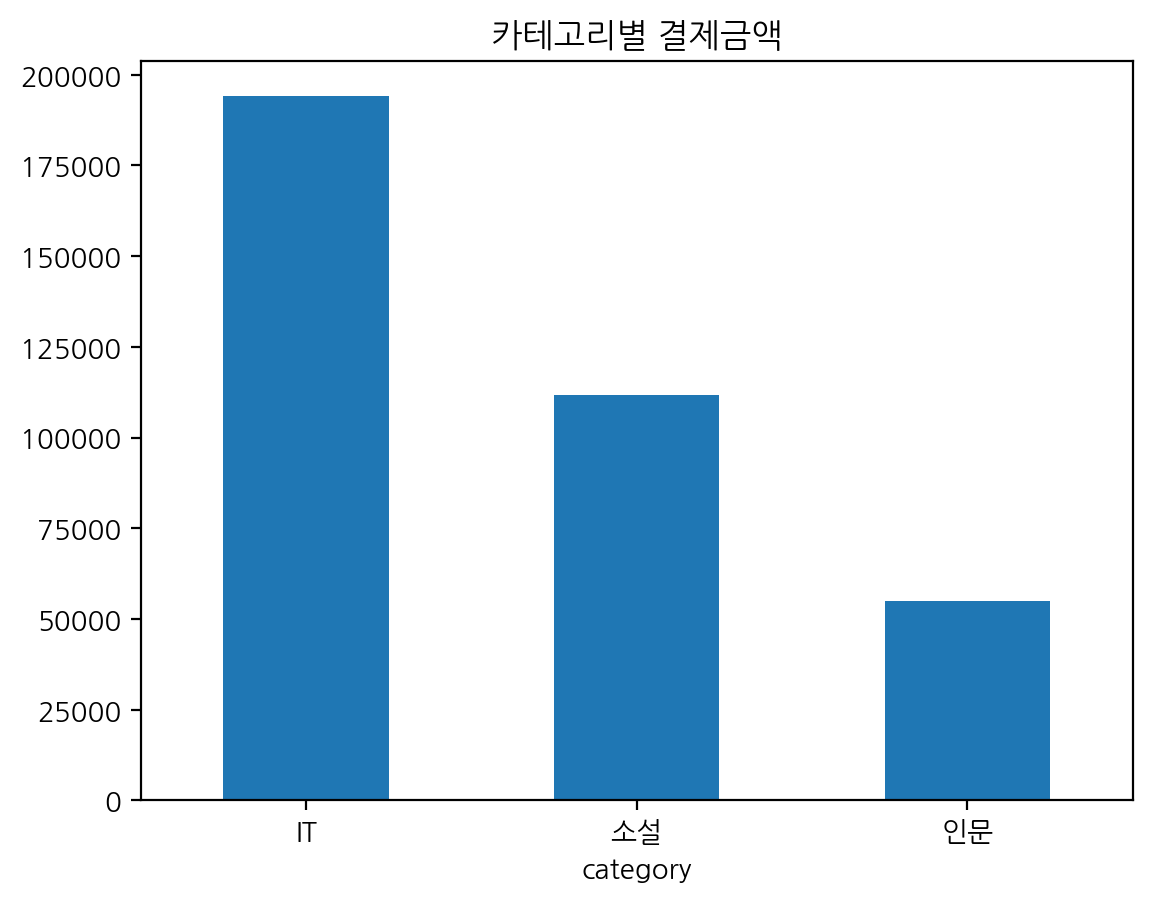

In [135]:
# 카테고리별 매출 막대 그래프
df.groupby("category")["pay"].sum().plot(kind="bar", title="카테고리별 결제금액")
plt.xticks(rotation=0)
plt.show()

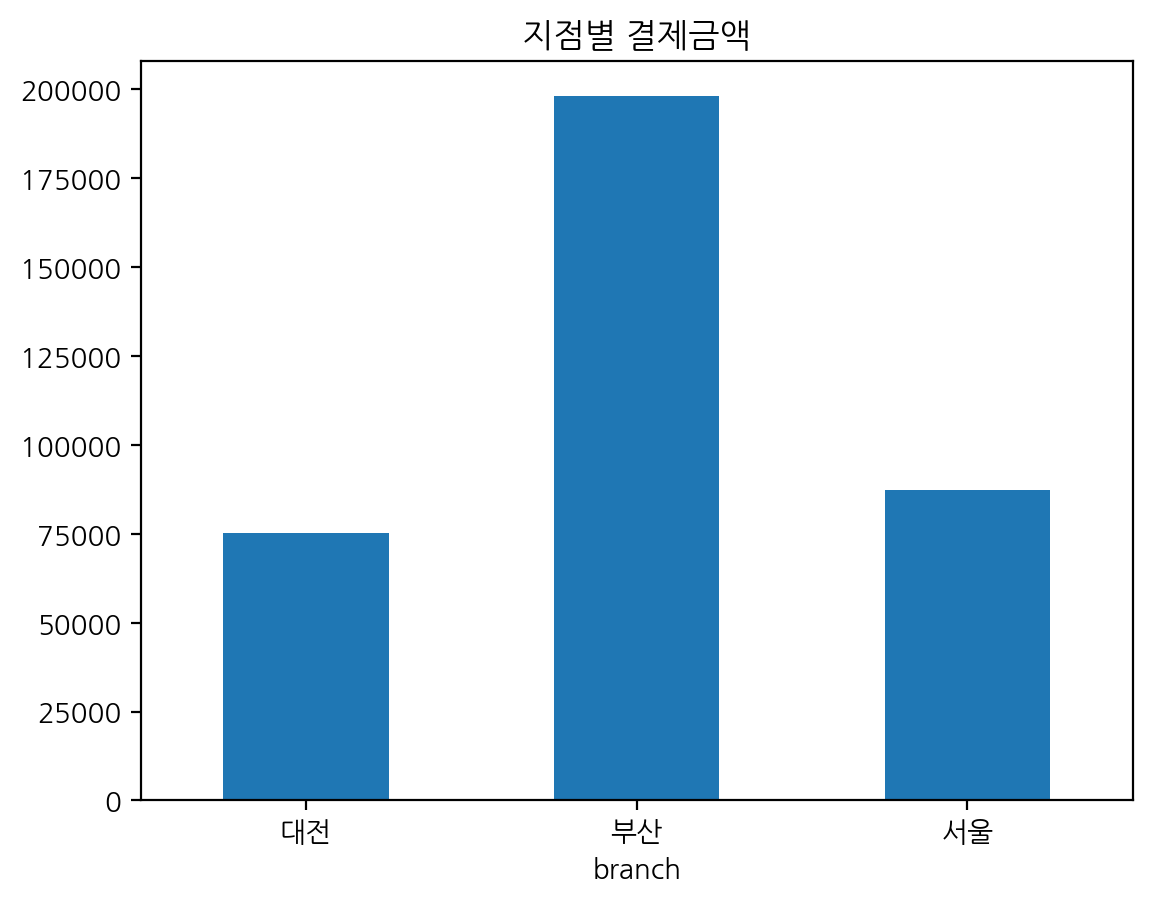

In [136]:
# 지점별 매출 막대 그래프
df.groupby("branch")["pay"].sum().plot(kind="bar", title="지점별 결제금액")
plt.xticks(rotation=0)
plt.show()

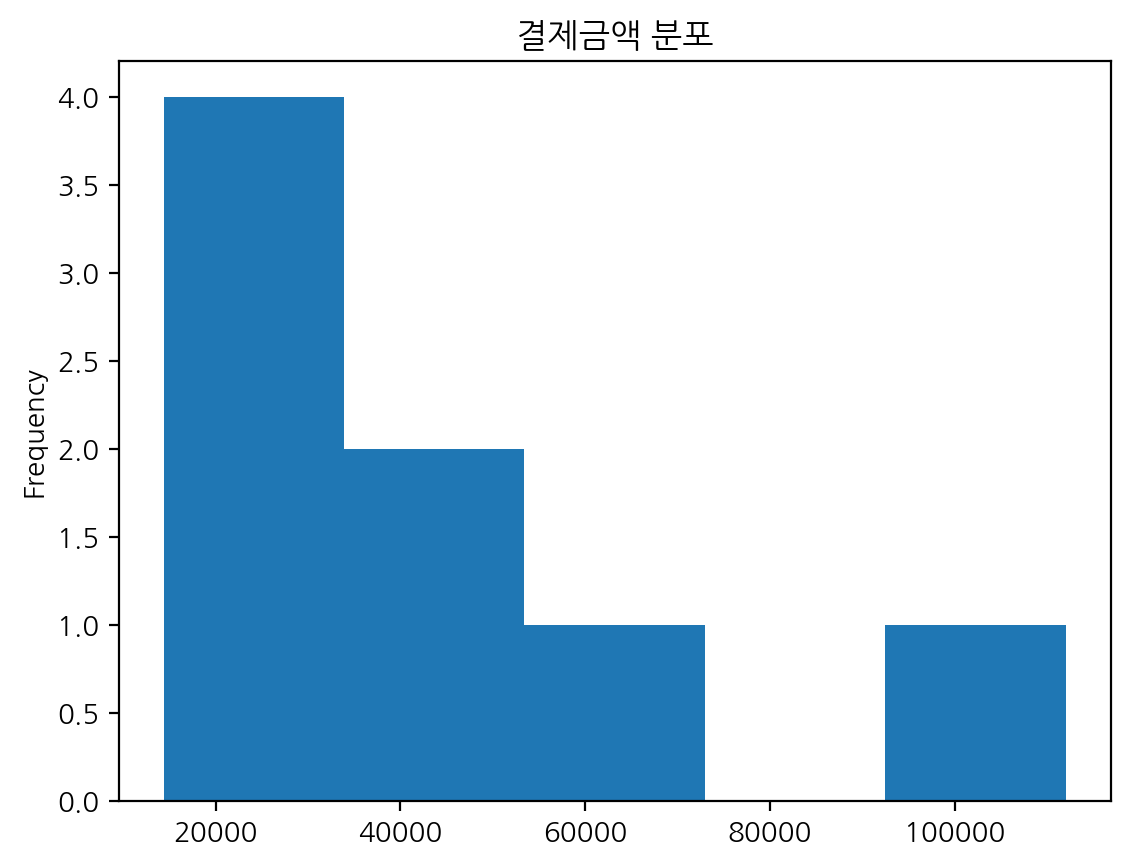

In [137]:
# 결제금액 히스토그램
df["pay"].plot(kind="hist", bins=5, title="결제금액 분포")
plt.show()

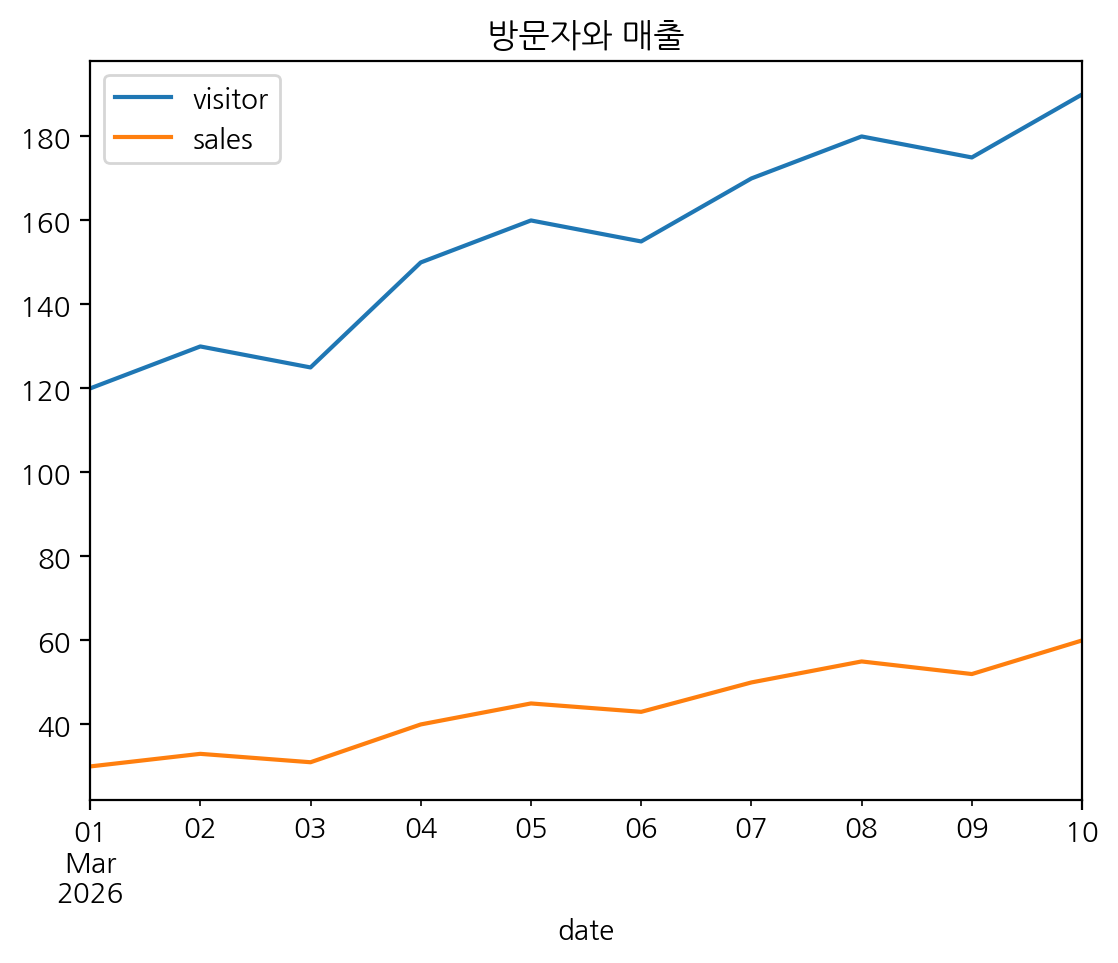

In [138]:
# 날짜 데이터 선 그래프
date_idx[["visitor", "sales"]].plot(title="방문자와 매출")
plt.show()

## 20. 결과 저장과 읽기

In [139]:
# CSV 저장
df.to_csv("12w_books_result.csv", index=False, encoding="utf-8-sig")

In [140]:
# CSV 읽기
pd.read_csv("12w_books_result.csv").head()

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label,pay_rank,branch_rank,branch_pay_mean,over_branch_mean,branch_cumsum,prev_pay,pay_diff,branch_order,member_text,summary,category_cat,pay_level_cat
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600.0,32400.0,중,회원,5.0,2.0,29100.0,True,32400.0,NaN,NaN,1,회원,서울-파이썬입문-32400,소설,중
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매,0.0,32000.0,중,비회원,6.0,3.0,66000.0,False,32000.0,NaN,NaN,1,비회원,부산-데이터분석-32000,IT,중
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매,4500.0,40500.0,중,회원,4.0,1.0,29100.0,True,72900.0,32400.0,8100.0,2,회원,서울-철학노트-40500,인문,중
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800.0,25200.0,하,회원,7.0,2.0,37600.0,False,25200.0,NaN,NaN,1,회원,대전-문학산책-25200,소설,하
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0.0,112000.0,상,비회원,1.0,1.0,66000.0,True,144000.0,32000.0,80000.0,2,비회원,부산-AI기초-112000,IT,상


In [141]:
# Excel 저장
df.to_excel("12w_books_result.xlsx", index=False)

In [142]:
# Excel 읽기
pd.read_excel("12w_books_result.xlsx").head()

,order_id,branch,category,book,qty,unit_price,member,sales,note,discount,pay,pay_level,member_label,pay_rank,branch_rank,branch_pay_mean,over_branch_mean,branch_cumsum,prev_pay,pay_diff,branch_order,member_text,summary,category_cat,pay_level_cat
0,1001,서울,소설,파이썬입문,2,18000,Y,36000,일반구매,3600,32400,중,회원,5,2,29100,True,32400,NaN,NaN,1,회원,서울-파이썬입문-32400,소설,중
1,1002,부산,IT,데이터분석,1,32000,N,32000,일반구매,0,32000,중,비회원,6,3,66000,False,32000,NaN,NaN,1,비회원,부산-데이터분석-32000,IT,중
2,1003,서울,인문,철학노트,3,15000,Y,45000,다량구매,4500,40500,중,회원,4,1,29100,True,72900,32400.0,8100.0,2,회원,서울-철학노트-40500,인문,중
3,1004,대전,소설,문학산책,2,14000,Y,28000,일반구매,2800,25200,하,회원,7,2,37600,False,25200,NaN,NaN,1,회원,대전-문학산책-25200,소설,하
4,1005,부산,IT,AI기초,4,28000,N,112000,다량구매,0,112000,상,비회원,1,1,66000,True,144000,32000.0,80000.0,2,비회원,부산-AI기초-112000,IT,상
